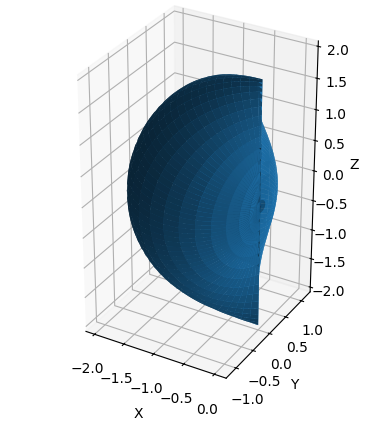

In [19]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Make data
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
theta = v  # polar angle
phi = u    # azimuthal angle

# Define a function depending on theta and phi, e.g., r = 1 + 0.5 * sin(theta) * cos(phi)
r = 1 - 3 * (np.cos(theta))**2

# Create meshgrid for r
R = np.outer(r, np.ones(np.size(phi)))

x = R * np.outer(np.cos(phi), np.sin(theta))
y = R * np.outer(np.sin(phi), np.sin(theta))
z = R * np.outer(np.ones(np.size(phi)), np.cos(theta))

# Plot the surface
ax.plot_surface(x, y, z)

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set an equal aspect ratio
ax.set_aspect('equal')

plt.show()

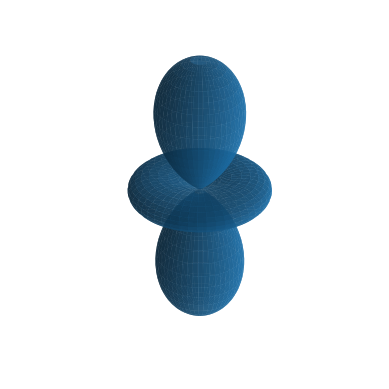

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Setup the 3D axis
ax = plt.axes(projection='3d')

# Define angular ranges
u = np.linspace(0, 2 * np.pi, 100) # phi (azimuthal)
v = np.linspace(0, np.pi, 100)     # theta (polar)

# Create a meshgrid to ensure all matrices are the same shape (100x100)
# This mimics the "same length" logic for 2D data structures
PHI, THETA = np.meshgrid(u, v)

# Define the function r(theta)
# Note: r is now a 2D matrix matching THETA and PHI
R = abs(1 - 3 * (np.cos(THETA))**2)  # Example function, can be changed as needed

# Convert Spherical to Cartesian coordinates
X = R * np.sin(THETA) * np.cos(PHI)
Y = R * np.sin(THETA) * np.sin(PHI)
Z = R * np.cos(THETA)

# Plot the surface with a colormap
surf = ax.plot_surface(X, Y, Z, edgecolor='none', alpha=0.8)

# Set labels and formatting
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.grid(False)
ax.axis('off')

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
# Ensure proportional axes so the shape isn't stretched
try:
    ax.set_aspect('equal')
except NotImplementedError:
    # Manual scaling for older matplotlib versions
    max_range = np.array([X.max()-X.min(), Y.max()-Y.min(), Z.max()-Z.min()]).max() / 2.0
    mid_x, mid_y, mid_z = (X.max()+X.min())*0.5, (Y.max()+Y.min())*0.5, (Z.max()+Z.min())*0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

# plt.savefig('spherical_surface.png')